# Multi-Event NTL Data Download Pipeline

## Overview
Unified download script for **10 disaster events** (6 original + 4 new):

| # | Event | City | Landfall | Type | Priority |
|---|-------|------|----------|------|----------|
| 1 | Hurricane Maria | San Juan, PR | 2017-09-20 | Hurricane | Original |
| 2 | Hurricane Michael | Panama City, FL | 2018-10-10 | Hurricane | Original |
| 3 | Puerto Rico Earthquake | San Juan, PR | 2020-01-07 | Earthquake | Original |
| 4 | Hurricane Ida | New Orleans, LA | 2021-08-29 | Hurricane | Original |
| 5 | Hurricane Laura | Lake Charles, LA | 2020-08-27 | Hurricane | Original |
| 6 | Hurricane Irma | Miami, FL | 2017-09-10 | Hurricane | Original |
| 7 | **Turkey-Hatay Earthquake** | **Antakya, TR** | **2023-02-06** | **Earthquake** | **NEW — P1** |
| 8 | **Hurricane Dorian** | **Freeport, Bahamas** | **2019-09-01** | **Hurricane** | **NEW — P2** |
| 9 | **Hurricane Ian** | **Fort Myers, FL** | **2022-09-28** | **Hurricane** | **NEW — P3** |
| 10 | **Hurricane Ian** | **Charlotte Harbor, FL** | **2022-09-28** | **Hurricane** | **NEW — P4** |

## Generalization Gap Being Addressed

| Gap | Original Problem | New Event Added |
|-----|-----------------|------------------|
| Earthquake only tied to San Juan | `earthquake_sanjuan` → island + high-urban | `earthquake_hatay` → continental + mid-urban |
| Island-type only Puerto Rico | Same geography, same urban scale | `dorian_freeport` → island + low-urban |
| No mid-urban coastal hurricane | `michael_panamacity` worst holdout | `ian_fortmyers` → mid-urban coastal |
| Low-urban coverage too thin | `laura_lakecharles` sole representative | `ian_charlotteharbor` → very low-urban coastal |

## Workflow
1. Select event(s) to process (set to **new events only** by default)
2. Query GEE for available VNP46A2 images
3. Screen cloud fraction per image
4. Export usable images to Google Drive (organized by event/period)
5. Generate VNP46A3 wget commands

## Output Folder Structure (Google Drive)
```
NTL_Backup_Generator/
├── Maria_SanJuan/VNP46A2/{pre,post}/          ← original
├── Michael_PanamaCity/VNP46A2/{pre,post}/      ← original
├── Earthquake_SanJuan/VNP46A2/{pre,post}/      ← original
├── Ida_NewOrleans/VNP46A2/{pre,post}/          ← original
├── Laura_LakeCharles/VNP46A2/{pre,post}/       ← original
├── Irma_Miami/VNP46A2/{pre,post}/              ← original
├── Earthquake_Hatay/VNP46A2/{pre,post}/        ← NEW
├── Dorian_Freeport/VNP46A2/{pre,post}/         ← NEW
├── Ian_FortMyers/VNP46A2/{pre,post}/           ← NEW
└── Ian_CharlotteHarbor/VNP46A2/{pre,post}/    ← NEW
```

## 1. Environment Setup

In [1]:
import ee
import pandas as pd
import time
from datetime import datetime, timedelta
from IPython.display import display, HTML

ee.Initialize(project="deductive-tempo-485113-n8")
print("✓ Google Earth Engine initialized")

/opt/anaconda3/envs/gee/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.15) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✓ Google Earth Engine initialized


## 2. All Event Configurations

In [2]:
# =============================================================================
# Master event registry — 10 disaster cases (6 original + 4 new)
# =============================================================================

EVENTS = {
    # -----------------------------------------------------------------
    # 1. Hurricane Maria — San Juan, PR
    # -----------------------------------------------------------------
    "maria_sanjuan": {
        "name":       "Hurricane Maria (San Juan)",
        "bounds":     [-66.20, 18.35, -65.95, 18.48],
        "landfall":   "2017-09-20",
        "pre_start":  "2017-08-01",
        "pre_end":    "2017-09-19",
        "post_start": "2017-09-20",
        "post_end":   "2017-12-31",
        "metric_crs": "EPSG:32619",
        "drive_root": "Maria_SanJuan",
        "a3_year":    2017,
        "a3_jdays":   {
            "182": "Jul 2017 (baseline 2)",
            "213": "Aug 2017 (primary baseline)",
            "244": "Sep 2017 (hurricane month)",
            "274": "Oct 2017 (recovery 1)",
            "305": "Nov 2017 (recovery 2)",
            "335": "Dec 2017 (recovery 3)",
        },
        "is_new": False,
    },

    # -----------------------------------------------------------------
    # 2. Hurricane Michael — Panama City, FL
    # -----------------------------------------------------------------
    "michael_panamacity": {
        "name":       "Hurricane Michael (Panama City)",
        "bounds":     [-85.80, 30.10, -85.55, 30.25],
        "landfall":   "2018-10-10",
        "pre_start":  "2018-09-15",
        "pre_end":    "2018-10-09",
        "post_start": "2018-10-10",
        "post_end":   "2018-11-30",
        "metric_crs": "EPSG:32616",
        "drive_root": "Michael_PanamaCity",
        "a3_year":    2018,
        "a3_jdays":   {
            "213": "Aug 2018 (baseline 2)",
            "244": "Sep 2018 (primary baseline)",
            "274": "Oct 2018 (hurricane month)",
            "305": "Nov 2018 (recovery 1)",
            "335": "Dec 2018 (recovery 2)",
        },
        "is_new": False,
    },

    # -----------------------------------------------------------------
    # 3. Puerto Rico Earthquake — San Juan, PR
    # -----------------------------------------------------------------
    "earthquake_sanjuan": {
        "name":       "Puerto Rico Earthquake (San Juan)",
        "bounds":     [-66.20, 18.35, -65.95, 18.48],
        "landfall":   "2020-01-07",
        "pre_start":  "2019-12-01",
        "pre_end":    "2020-01-06",
        "post_start": "2020-01-07",
        "post_end":   "2020-02-15",
        "metric_crs": "EPSG:32619",
        "drive_root": "Earthquake_SanJuan",
        # VNP46A3 cross-year: baseline in 2019, event months in 2020
        "a3_year":    2019,
        "a3_jdays":   {
            "305": "Nov 2019 (baseline 2)",
            "335": "Dec 2019 (primary baseline)",
        },
        "a3_year_post": 2020,
        "a3_jdays_post": {
            "001": "Jan 2020 (earthquake month)",
            "032": "Feb 2020 (recovery)",
        },
        "has_eaglei": False,
        "is_new": False,
    },

    # -----------------------------------------------------------------
    # 4. Hurricane Ida — New Orleans, LA
    # -----------------------------------------------------------------
    "ida_neworleans": {
        "name":       "Hurricane Ida (New Orleans)",
        "bounds":     [-90.20, 29.87, -89.90, 30.08],
        "landfall":   "2021-08-29",
        "pre_start":  "2021-08-09",
        "pre_end":    "2021-08-28",
        "post_start": "2021-08-29",
        "post_end":   "2021-10-31",
        "metric_crs": "EPSG:32615",
        "drive_root": "Ida_NewOrleans",
        "a3_year":    2021,
        "a3_jdays":   {
            "182": "Jul 2021 (baseline 2)",
            "213": "Aug 2021 (hurricane month)",
            "244": "Sep 2021 (recovery 1)",
            "274": "Oct 2021 (recovery 2)",
            "305": "Nov 2021 (recovery 3)",
        },
        "has_eaglei": True,
        "is_new": False,
    },

    # -----------------------------------------------------------------
    # 5. Hurricane Laura — Lake Charles, LA
    # -----------------------------------------------------------------
    "laura_lakecharles": {
        "name":       "Hurricane Laura (Lake Charles)",
        "bounds":     [-93.35, 30.10, -93.05, 30.30],
        "landfall":   "2020-08-27",
        "pre_start":  "2020-08-07",
        "pre_end":    "2020-08-26",
        "post_start": "2020-08-27",
        "post_end":   "2020-11-30",
        "metric_crs": "EPSG:32615",
        "drive_root": "Laura_LakeCharles",
        "a3_year":    2020,
        "a3_jdays":   {
            "182": "Jul 2020 (baseline 2)",
            "213": "Aug 2020 (hurricane month)",
            "244": "Sep 2020 (recovery 1)",
            "274": "Oct 2020 (recovery 2)",
            "305": "Nov 2020 (recovery 3)",
        },
        "has_eaglei": True,
        "is_new": False,
    },

    # -----------------------------------------------------------------
    # 6. Hurricane Irma — Miami, FL
    # -----------------------------------------------------------------
    "irma_miami": {
        "name":       "Hurricane Irma (Miami)",
        "bounds":     [-80.35, 25.70, -80.10, 25.90],
        "landfall":   "2017-09-10",
        "pre_start":  "2017-08-20",
        "pre_end":    "2017-09-09",
        "post_start": "2017-09-10",
        "post_end":   "2017-10-31",
        "metric_crs": "EPSG:32617",
        "drive_root": "Irma_Miami",
        "a3_year":    2017,
        "a3_jdays":   {
            "182": "Jul 2017 (baseline 2)",
            "213": "Aug 2017 (primary baseline)",
            "244": "Sep 2017 (hurricane month)",
            "274": "Oct 2017 (recovery 1)",
            "305": "Nov 2017 (recovery 2)",
        },
        "has_eaglei": True,
        "is_new": False,
    },

    # =================================================================
    # NEW EVENTS — added to improve cross-event generalization
    # =================================================================

    # -----------------------------------------------------------------
    # 7. Turkey-Hatay Earthquake [NEW — Priority 1]
    #    Rationale: breaks earthquake-SanJuan coupling;
    #               continental, mid-urban, completely different geography
    #    Note: international event -> no EAGLE-I; winter -> snow flag active
    # -----------------------------------------------------------------
    "earthquake_hatay": {
        "name":       "Turkey-Hatay Earthquake (Antakya)",
        "bounds":     [36.05, 36.10, 36.42, 36.32],
        "landfall":   "2023-02-06",
        "pre_start":  "2022-12-01",
        "pre_end":    "2023-02-05",
        "post_start": "2023-02-06",
        "post_end":   "2023-04-30",
        "metric_crs": "EPSG:32637",  # UTM zone 37N covers Hatay province
        "drive_root": "Earthquake_Hatay",
        # Cross-year A3: baseline in 2022, event/recovery months in 2023
        "a3_year":    2022,
        "a3_jdays":   {
            "305": "Nov 2022 (baseline 2)",
            "335": "Dec 2022 (primary baseline)",
        },
        "a3_year_post": 2023,
        "a3_jdays_post": {
            "001": "Jan 2023 (immediate pre)",
            "032": "Feb 2023 (earthquake month)",
            "060": "Mar 2023 (recovery 1)",
            "091": "Apr 2023 (recovery 2)",
        },
        "has_eaglei":    False,  # international event; use NTL drop as outage proxy
        "snow_caution":  True,   # February snow common in southern Turkey highlands
        "is_new":        True,
    },

    # -----------------------------------------------------------------
    # 8. Hurricane Dorian — Freeport, Grand Bahama [NEW — Priority 2]
    #    Rationale: breaks island-PR coupling;
    #               island topology but much smaller/different city than San Juan
    # -----------------------------------------------------------------
    "dorian_freeport": {
        "name":       "Hurricane Dorian (Freeport, Bahamas)",
        "bounds":     [-78.82, 26.42, -78.28, 26.72],
        "landfall":   "2019-09-01",
        "pre_start":  "2019-07-15",
        "pre_end":    "2019-08-31",
        "post_start": "2019-09-01",
        "post_end":   "2019-11-30",
        "metric_crs": "EPSG:32618",  # UTM zone 18N
        "drive_root": "Dorian_Freeport",
        "a3_year":    2019,
        "a3_jdays":   {
            "182": "Jul 2019 (baseline 2)",
            "213": "Aug 2019 (primary baseline)",
            "244": "Sep 2019 (hurricane month)",
            "274": "Oct 2019 (recovery 1)",
            "305": "Nov 2019 (recovery 2)",
        },
        "has_eaglei": False,  # Bahamas; use NTL drop as outage proxy
        "is_new":     True,
    },

    # -----------------------------------------------------------------
    # 9. Hurricane Ian — Fort Myers, FL [NEW — Priority 3]
    #    Rationale: mid-urban coastal hurricane; bridges the
    #               Panama City gap identified in holdout analysis
    # -----------------------------------------------------------------
    "ian_fortmyers": {
        "name":       "Hurricane Ian (Fort Myers)",
        "bounds":     [-82.02, 26.50, -81.72, 26.76],
        "landfall":   "2022-09-28",
        "pre_start":  "2022-08-15",
        "pre_end":    "2022-09-27",
        "post_start": "2022-09-28",
        "post_end":   "2022-12-31",
        "metric_crs": "EPSG:32617",  # UTM zone 17N
        "drive_root": "Ian_FortMyers",
        "a3_year":    2022,
        "a3_jdays":   {
            "182": "Jul 2022 (baseline 2)",
            "213": "Aug 2022 (primary baseline)",
            "244": "Sep 2022 (hurricane month)",
            "274": "Oct 2022 (recovery 1)",
            "305": "Nov 2022 (recovery 2)",
            "335": "Dec 2022 (recovery 3)",
        },
        "has_eaglei": True,  # Florida — full EAGLE-I coverage
        "is_new":     True,
    },

    # -----------------------------------------------------------------
    # 10. Hurricane Ian — Charlotte Harbor, FL [NEW — Priority 4]
    #     Rationale: low-urban coastal; same Ian event but different bbox;
    #                run alongside ian_fortmyers to share GEE downloads
    # -----------------------------------------------------------------
    "ian_charlotteharbor": {
        "name":       "Hurricane Ian (Charlotte Harbor)",
        "bounds":     [-82.12, 26.80, -81.88, 27.02],
        "landfall":   "2022-09-28",
        "pre_start":  "2022-08-15",
        "pre_end":    "2022-09-27",
        "post_start": "2022-09-28",
        "post_end":   "2022-12-31",
        "metric_crs": "EPSG:32617",
        "drive_root": "Ian_CharlotteHarbor",
        "a3_year":    2022,
        "a3_jdays":   {
            "182": "Jul 2022 (baseline 2)",
            "213": "Aug 2022 (primary baseline)",
            "244": "Sep 2022 (hurricane month)",
            "274": "Oct 2022 (recovery 1)",
            "305": "Nov 2022 (recovery 2)",
            "335": "Dec 2022 (recovery 3)",
        },
        "has_eaglei": True,
        "is_new":     True,
    },
}

print(f"✓ {len(EVENTS)} events registered:")
for eid, cfg in EVENTS.items():
    tag = " ★ NEW" if cfg.get("is_new") else ""
    print(f"  • {eid:28s} → {cfg['name']}{tag}")


✓ 6 events registered:
  • maria_sanjuan             → Hurricane Maria (San Juan)
  • michael_panamacity        → Hurricane Michael (Panama City)
  • earthquake_sanjuan        → Puerto Rico Earthquake (San Juan)
  • ida_neworleans            → Hurricane Ida (New Orleans)
  • laura_lakecharles         → Hurricane Laura (Lake Charles)
  • irma_miami                → Hurricane Irma (Miami)


## 2.5 Study Area Overview

Visualize all 10 research sites on a map. **Run this cell at any time** — no GEE connection required.

> Requires `cartopy` for the basemap version.  
> If not installed: `conda install -c conda-forge cartopy`  
> A simplified fallback (no basemap) runs automatically if cartopy is missing.

In [ ]:
# =============================================================================
# Study area overview map — all 10 disaster events
# Left panel: Americas (9 events)  |  Right panel: Turkey inset (1 event)
# Requires: matplotlib, cartopy (falls back to plain scatter if unavailable)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not found. Install with: conda install -c conda-forge cartopy")

# --- Centroid and label positions for each event ---
PLOT_META = {
    "maria_sanjuan":       {"lon": -66.08, "lat": 18.41, "label": "Maria\n(San Juan)",     "dx":  0.5, "dy":  0.4},
    "michael_panamacity":  {"lon": -85.67, "lat": 30.17, "label": "Michael\n(Panama City)", "dx": -6.0, "dy":  0.6},
    "earthquake_sanjuan":  {"lon": -66.08, "lat": 18.41, "label": "EQ\n(San Juan)",         "dx":  0.5, "dy": -1.0},
    "ida_neworleans":      {"lon": -90.05, "lat": 29.97, "label": "Ida\n(New Orleans)",     "dx": -6.0, "dy": -1.3},
    "laura_lakecharles":   {"lon": -93.20, "lat": 30.20, "label": "Laura\n(Lake Charles)",  "dx": -8.0, "dy":  0.6},
    "irma_miami":          {"lon": -80.22, "lat": 25.80, "label": "Irma\n(Miami)",           "dx":  0.5, "dy": -1.1},
    "earthquake_hatay":    {"lon": 36.23,  "lat": 36.21, "label": "EQ Hatay",                "dx":  0.5, "dy":  0.5},
    "dorian_freeport":     {"lon": -78.55, "lat": 26.57, "label": "Dorian\n(Freeport)",     "dx":  0.5, "dy":  0.6},
    "ian_fortmyers":       {"lon": -81.87, "lat": 26.63, "label": "Ian\n(Ft Myers)",         "dx":  0.5, "dy": -1.1},
    "ian_charlotteharbor": {"lon": -82.00, "lat": 26.91, "label": "Ian\n(Charlotte H.)",    "dx":  0.5, "dy":  0.4},
}

COLORS = {
    "earthquake": "#C0392B",  # red
    "hurricane":  "#1A5276",  # deep blue
}

def get_color(eid):
    return COLORS["earthquake"] if "earthquake" in eid else COLORS["hurricane"]

def get_marker(eid):
    # Star for new events, circle for originals
    return "*" if EVENTS[eid].get("is_new") else "o"

def get_msize(eid):
    return 260 if EVENTS[eid].get('is_new') else 120

AMERICAS = [e for e in EVENTS if e != 'earthquake_hatay']
TURKEY   = ['earthquake_hatay']

if HAS_CARTOPY:
    fig = plt.figure(figsize=(18, 9))
    fig.patch.set_facecolor("#F7F9FC")

    # Main Americas panel
    ax_main = fig.add_axes([0.02, 0.06, 0.62, 0.88], projection=ccrs.PlateCarree())
    # Turkey inset
    ax_tr   = fig.add_axes([0.67, 0.50, 0.30, 0.42], projection=ccrs.PlateCarree())

    def style_ax(ax, extent, title=''):
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND,      facecolor="#EEF0E5", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="#C8DCF0", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="#888", zorder=1)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#AAAAAA", linestyle=":", zorder=1)
        ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#CCCCCC", zorder=1)
        ax.add_feature(cfeature.LAKES,     facecolor="#C8DCF0", zorder=0)
        ax.gridlines(draw_labels=True, linewidth=0.3, color='gray',
                     alpha=0.5, linestyle='--', x_inline=False, y_inline=False)
        if title:
            ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

    style_ax(ax_main, [-100, -58, 16, 36], 'Study Sites — Americas (9 events)')
    style_ax(ax_tr,   [33.0, 35.0, 40.0, 38.5], 'Turkey-Hatay Earthquake  ★ NEW')

    def plot_event(ax, eid):
        meta   = PLOT_META[eid]
        cfg    = EVENTS[eid]
        w, s, e, n = cfg['bounds']
        color  = get_color(eid)
        marker = get_marker(eid)
        msize  = get_msize(eid)
        # Bounding box shading
        ax.add_patch(mpatches.Rectangle(
            (w, s), e - w, n - s,
            linewidth=1.6, edgecolor=color, facecolor=color, alpha=0.20,
            transform=ccrs.PlateCarree(), zorder=2
        ))
        # Point marker
        ax.scatter(meta['lon'], meta['lat'], s=msize, c=color, marker=marker,
                   edgecolors='white', linewidths=0.7,
                   transform=ccrs.PlateCarree(), zorder=4)
        # Annotation
        ax.annotate(
            meta['label'],
            xy=(meta['lon'], meta['lat']),
            xytext=(meta['lon'] + meta['dx'], meta['lat'] + meta['dy']),
            fontsize=7.5,
            fontweight='bold' if cfg.get('is_new') else 'normal',
            color=color,
            transform=ccrs.PlateCarree(), ha='left',
            arrowprops=dict(arrowstyle='-', color=color, lw=0.7),
            zorder=5
        )

    for eid in AMERICAS: plot_event(ax_main, eid)
    for eid in TURKEY:   plot_event(ax_tr,   eid)

    # Highlight Turkey inset border in earthquake red
    for spine in ax_tr.spines.values():
        spine.set_edgecolor(COLORS['earthquake'])
        spine.set_linewidth(2.2)

    # Legend
    legend_items = [
        mlines.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['hurricane'],
                      markersize=9,  label='Hurricane (original)'),
        mlines.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['earthquake'],
                      markersize=9,  label='Earthquake (original)'),
        mlines.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLORS['hurricane'],
                      markersize=13, label='Hurricane  ★ NEW'),
        mlines.Line2D([0],[0], marker='*', color='w', markerfacecolor=COLORS['earthquake'],
                      markersize=13, label='Earthquake ★ NEW'),
        mpatches.Patch(facecolor=COLORS['hurricane'],  alpha=0.20, label='Study bounding box (hurricane)'),
        mpatches.Patch(facecolor=COLORS['earthquake'], alpha=0.20, label='Study bounding box (earthquake)'),
    ]
    ax_main.legend(handles=legend_items, loc='lower left', fontsize=8,
                   title='Disaster Type', title_fontsize=8.5,
                   framealpha=0.92, edgecolor='#CCCCCC')

    # Titles
    fig.text(0.5, 0.98, 'NTL Backup Generator Research — All Study Sites (10 Events)',
             ha='center', va='top', fontsize=13, fontweight='bold')
    fig.text(0.5, 0.945,
             '★ = newly added events to improve cross-event generalization',
             ha='center', va='top', fontsize=9, color='#555555')

    plt.savefig('study_area_overview.png', dpi=180, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print('✓ Saved: study_area_overview.png')

else:
    # Fallback: simple lon/lat scatter with no basemap
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    def simple_panel(ax, eids, title, xlim, ylim):
        ax.set_facecolor('#C8DCF0')
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        ax.grid(True, linewidth=0.4, alpha=0.5)
        for eid in eids:
            meta = PLOT_META[eid]
            cfg  = EVENTS[eid]
            w, s, e, n = cfg['bounds']
            color = get_color(eid)
            rect = mpatches.Rectangle((w, s), e-w, n-s,
                                       edgecolor=color, facecolor=color,
                                       alpha=0.25, linewidth=1.4)
            ax.add_patch(rect)
            ax.scatter(meta['lon'], meta['lat'], s=get_msize(eid)/8,
                       c=color, marker=get_marker(eid),
                       edgecolors='white', linewidths=0.5, zorder=4)
            ax.annotate(meta['label'].replace('\n', ' '),
                        xy=(meta['lon'], meta['lat']),
                        xytext=(meta['lon']+meta['dx'], meta['lat']+meta['dy']),
                        fontsize=7, color=color,
                        arrowprops=dict(arrowstyle='-', color=color, lw=0.6))

    simple_panel(axes[0], AMERICAS, 'Americas (9 events)', [-105, -55], [14, 38])
    simple_panel(axes[1], TURKEY,   'Turkey-Hatay EQ',    [30, 42],    [33, 40])
    plt.tight_layout()
    plt.savefig('study_area_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved: study_area_overview.png (simplified — install cartopy for basemap)')


## 3. Select Event(s) to Process

Set `SELECTED_EVENTS` to control which events to download.  
- Use `"all"` to process every event  
- Or provide a list of event IDs, e.g. `["ida_neworleans", "irma_miami"]`

In [3]:
# =============================================================================
# SELECT WHICH EVENTS TO PROCESS
# Default: new events only — existing folders are NOT re-downloaded
# To re-run originals, add their IDs, or set SELECTED_EVENTS = 'all'
# =============================================================================

# Only the 4 new events (originals already downloaded)
SELECTED_EVENTS = [
    "earthquake_hatay",     # Priority 1 — urban earthquake, non-San Juan
    "dorian_freeport",      # Priority 2 — island, non-PR
    "ian_fortmyers",        # Priority 3 — mid-urban coastal hurricane
    "ian_charlotteharbor",  # Priority 4 — low-urban coastal hurricane
]

# Uncomment to process ALL 10 events (full refresh)
# SELECTED_EVENTS = 'all'

# --- Global settings ---
MAX_CLOUD_FRACTION = 0.3  # Cloud fraction threshold
EXPORT_SCALE = 500        # meters

# --- GEE dataset constants ---
VNP46A2    = ee.ImageCollection("NASA/VIIRS/002/VNP46A2")
NTL_BAND   = "Gap_Filled_DNB_BRDF_Corrected_NTL"
CLOUD_BAND = "QF_Cloud_Mask"
SNOW_BAND  = "Snow_Flag"
NTL_SCALE  = 0.1

# --- Resolve selection ---
if SELECTED_EVENTS == 'all':
    events_to_run = list(EVENTS.keys())
else:
    events_to_run = SELECTED_EVENTS

print(f"Will process {len(events_to_run)} event(s):")
for eid in events_to_run:
    cfg = EVENTS[eid]
    tag = " ★" if cfg.get("is_new") else ""
    print(f"  • {cfg['name']}{tag}  |  pre: {cfg['pre_start']}→{cfg['pre_end']}  |  post: {cfg['post_start']}→{cfg['post_end']}")


Will process 3 event(s):
  • Hurricane Ida (New Orleans)  |  pre: 2021-08-09→2021-08-28  |  post: 2021-08-29→2021-10-31
  • Hurricane Laura (Lake Charles)  |  pre: 2020-08-07→2020-08-26  |  post: 2020-08-27→2020-11-30
  • Hurricane Irma (Miami)  |  pre: 2017-08-20→2017-09-09  |  post: 2017-09-10→2017-10-31


## 4. Cloud Mask & Quality Assessment Functions

In [4]:
def extract_bits(img, band, start_bit, end_bit):
    """Extract specific bit range from QA band."""
    nbits = end_bit - start_bit + 1
    mask = (1 << nbits) - 1
    return img.select(band).rightShift(start_bit).bitwiseAnd(mask)


def compute_cloud_fraction(roi):
    """Return a function that computes cloud fraction for a given ROI."""
    def _inner(img):
        cloud_state = extract_bits(img, CLOUD_BAND, 6, 7)
        cloudy = cloud_state.gte(2)
        shadow = extract_bits(img, CLOUD_BAND, 8, 8).eq(1)
        cirrus = extract_bits(img, CLOUD_BAND, 9, 9).eq(1)
        contaminated = cloudy.Or(shadow).Or(cirrus)
        stats = contaminated.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi,
            scale=EXPORT_SCALE,
            maxPixels=1e9
        )
        return img.set({
            'cloud_fraction': stats.get(CLOUD_BAND),
            'date_str': img.date().format('YYYY-MM-dd')
        })
    return _inner


def apply_qa_and_scale(img):
    """Apply QA mask and scale factor to VNP46A2 image."""
    img = ee.Image(img)
    cloud_state = extract_bits(img, CLOUD_BAND, 6, 7)
    clear = cloud_state.lte(1)
    shadow = extract_bits(img, CLOUD_BAND, 8, 8).eq(1)
    cirrus = extract_bits(img, CLOUD_BAND, 9, 9).eq(1)
    valid_mask = clear.And(shadow.Not()).And(cirrus.Not())
    ntl = img.select(NTL_BAND).multiply(NTL_SCALE)
    return ntl.updateMask(valid_mask).rename('NTL')


def query_period(roi, date_start, date_end):
    """Query VNP46A2 images and compute cloud fraction for a time window."""
    col = VNP46A2.filterBounds(roi).filterDate(date_start, date_end)
    screened = col.map(compute_cloud_fraction(roi))
    
    def img_to_feature(img):
        return ee.Feature(None, {
            'date_str': img.get('date_str'),
            'cloud_fraction': img.get('cloud_fraction')
        })
    
    fc = ee.FeatureCollection(screened.map(img_to_feature))
    records = fc.getInfo()['features']
    df = pd.DataFrame([
        {'date': r['properties'].get('date_str'),
         'cloud_fraction': r['properties'].get('cloud_fraction')}
        for r in records
    ])
    df = df.dropna(subset=['cloud_fraction', 'date']).reset_index(drop=True)
    return df


print("✓ Functions defined")

✓ Functions defined


## 5. Query & Screen All Images (Per Event)

This cell loops through selected events, queries GEE, and stores screening results.  
**This is the most time-consuming step** — each event takes ~1–3 min depending on image count.

In [5]:
# =============================================================================
# Query all images for each selected event
# Results stored in screening_results dict
# =============================================================================

screening_results = {}

for eid in events_to_run:
    cfg = EVENTS[eid]
    roi = ee.Geometry.Rectangle(cfg['bounds'])
    
    print("=" * 70)
    print(f"Querying: {cfg['name']}")
    print(f"  Pre:  {cfg['pre_start']} → {cfg['pre_end']}")
    print(f"  Post: {cfg['post_start']} → {cfg['post_end']}")
    print("=" * 70)
    
    # Query pre-disaster
    print("  Querying pre-disaster images...", end=" ")
    pre_df = query_period(roi, cfg['pre_start'], cfg['pre_end'])
    pre_df['period'] = 'pre'
    print(f"{len(pre_df)} images found")
    
    # Query post-disaster
    print("  Querying post-disaster images...", end=" ")
    post_df = query_period(roi, cfg['post_start'], cfg['post_end'])
    post_df['period'] = 'post'
    print(f"{len(post_df)} images found")
    
    # Combine
    all_df = pd.concat([pre_df, post_df], ignore_index=True)
    all_df['usable'] = all_df['cloud_fraction'] < MAX_CLOUD_FRACTION
    all_df['cloud_pct'] = (all_df['cloud_fraction'] * 100).round(1)
    
    # Store
    screening_results[eid] = all_df
    
    n_pre_ok  = all_df[(all_df['period']=='pre')  & all_df['usable']].shape[0]
    n_post_ok = all_df[(all_df['period']=='post') & all_df['usable']].shape[0]
    print(f"  → Usable: {n_pre_ok} pre + {n_post_ok} post = {n_pre_ok + n_post_ok} total")
    print()

print("\n✓ All events queried.")

Querying: Hurricane Ida (New Orleans)
  Pre:  2021-08-09 → 2021-08-28
  Post: 2021-08-29 → 2021-10-31
  Querying pre-disaster images... 19 images found
  Querying post-disaster images... 63 images found
  → Usable: 10 pre + 35 post = 45 total

Querying: Hurricane Laura (Lake Charles)
  Pre:  2020-08-07 → 2020-08-26
  Post: 2020-08-27 → 2020-11-30
  Querying pre-disaster images... 19 images found
  Querying post-disaster images... 95 images found
  → Usable: 16 pre + 63 post = 79 total

Querying: Hurricane Irma (Miami)
  Pre:  2017-08-20 → 2017-09-09
  Post: 2017-09-10 → 2017-10-31
  Querying pre-disaster images... 19 images found
  Querying post-disaster images... 50 images found
  → Usable: 9 pre + 27 post = 36 total


✓ All events queried.


## 6. Image Quality Summary & Visualization

In [6]:
# =============================================================================
# Print summary table for each event
# =============================================================================

summary_rows = []
for eid in events_to_run:
    cfg = EVENTS[eid]
    df = screening_results[eid]
    for period in ['pre', 'post']:
        sub = df[df['period'] == period]
        summary_rows.append({
            'event': eid,
            'period': period,
            'total_images': len(sub),
            'usable_images': sub['usable'].sum(),
            'avg_cloud_%': round(sub['cloud_fraction'].mean() * 100, 1),
            'min_cloud_%': round(sub['cloud_fraction'].min() * 100, 1),
        })

summary_df = pd.DataFrame(summary_rows)
print(f"IMAGE QUALITY SUMMARY  (threshold: {MAX_CLOUD_FRACTION:.0%})")
print("=" * 80)
display(summary_df)

IMAGE QUALITY SUMMARY  (threshold: 30%)


,event,period,total_images,usable_images,avg_cloud_%,min_cloud_%
0,ida_neworleans,pre,19,10,40.9,0.0
1,ida_neworleans,post,63,35,38.6,0.0
2,laura_lakecharles,pre,19,16,14.6,0.0
3,laura_lakecharles,post,95,63,30.2,0.0
4,irma_miami,pre,19,9,50.0,0.5
5,irma_miami,post,50,27,43.6,0.0


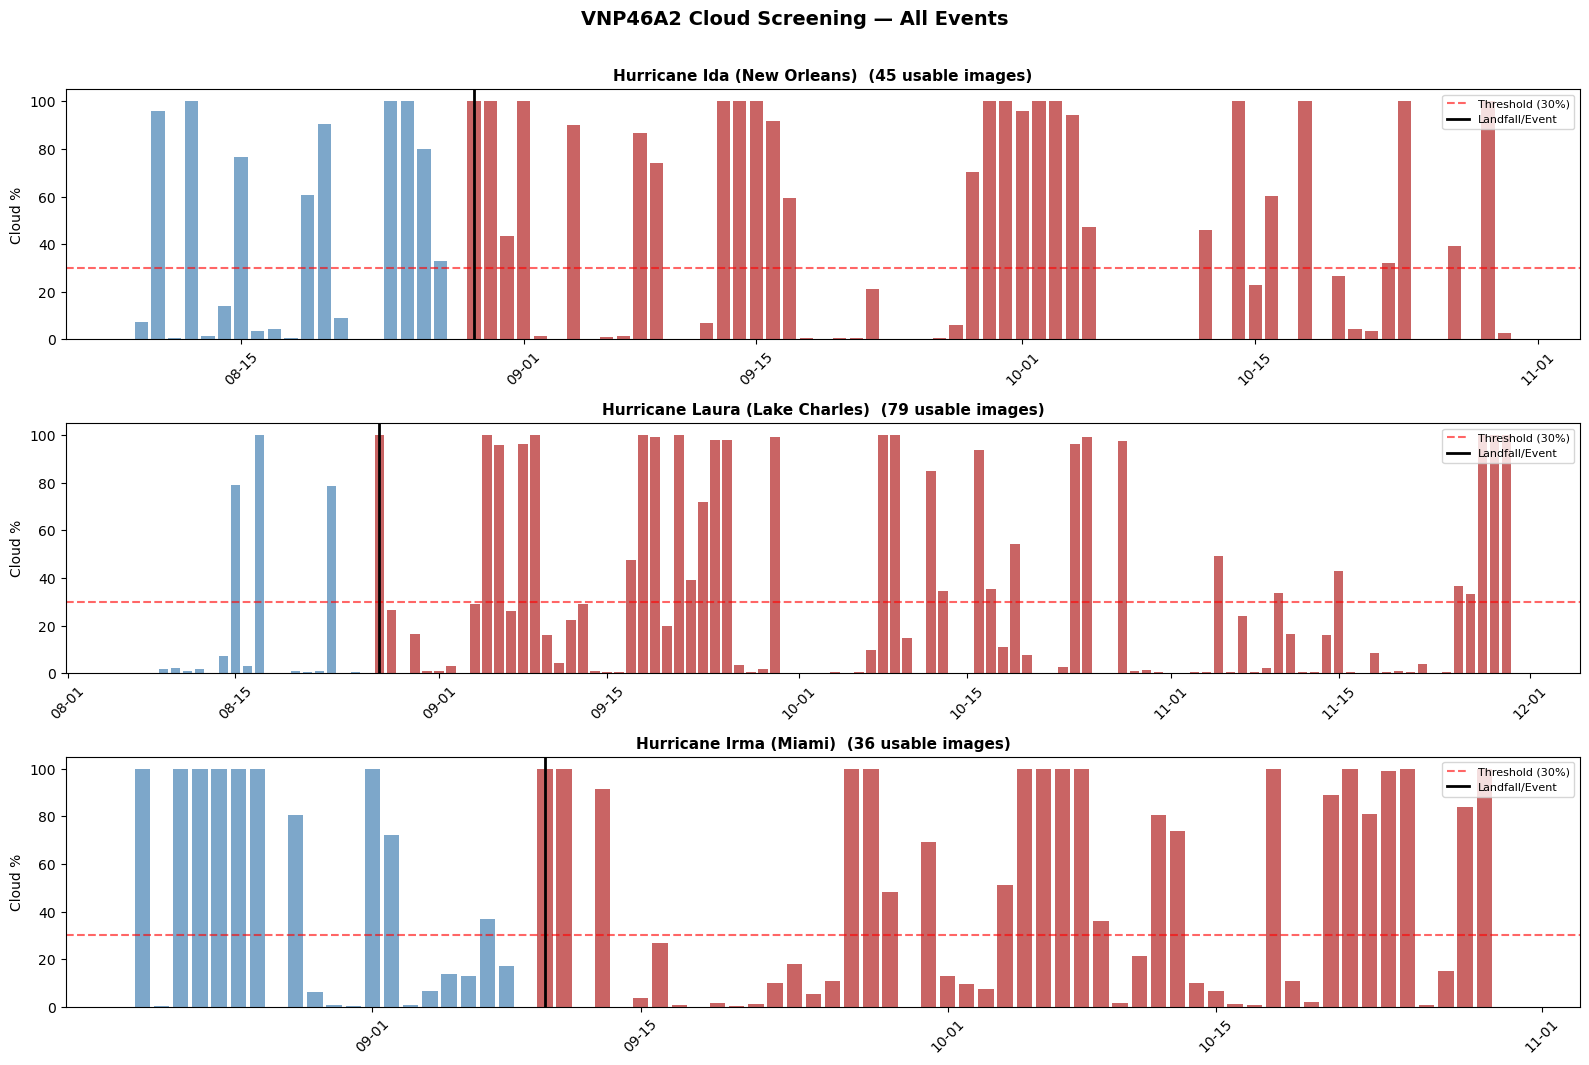

✓ Saved: cloud_screening_all_events.png


In [7]:
# =============================================================================
# Visualize cloud fraction timelines — one subplot per event
# =============================================================================
try:
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    
    n_events = len(events_to_run)
    fig, axes = plt.subplots(n_events, 1, figsize=(16, 3.5 * n_events), squeeze=False)
    
    for idx, eid in enumerate(events_to_run):
        ax = axes[idx, 0]
        cfg = EVENTS[eid]
        df = screening_results[eid].copy()
        df['date_dt'] = pd.to_datetime(df['date'])
        
        colors = df['period'].map({'pre': 'steelblue', 'post': 'firebrick'})
        ax.bar(df['date_dt'], df['cloud_fraction'] * 100, color=colors, alpha=0.7, width=0.8)
        ax.axhline(y=MAX_CLOUD_FRACTION * 100, color='red', linestyle='--', 
                   alpha=0.6, label=f'Threshold ({MAX_CLOUD_FRACTION:.0%})')
        ax.axvline(x=pd.Timestamp(cfg['landfall']), color='black', linestyle='-', 
                   lw=2, label='Landfall/Event')
        
        n_usable = df['usable'].sum()
        ax.set_ylabel('Cloud %')
        ax.set_title(f"{cfg['name']}  ({n_usable} usable images)", fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_ylim(0, 105)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle('VNP46A2 Cloud Screening — All Events', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'cloud_screening_all_events.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: cloud_screening_all_events.png")

except ImportError:
    print("matplotlib not available, skipping plot")

## 7. Prepare Download Lists

In [8]:
# =============================================================================
# Build per-event download date lists
# =============================================================================

download_lists = {}

for eid in events_to_run:
    df = screening_results[eid]
    pre_dates  = df[(df['period']=='pre')  & df['usable']].sort_values('cloud_fraction')['date'].tolist()
    post_dates = df[(df['period']=='post') & df['usable']].sort_values('cloud_fraction')['date'].tolist()
    download_lists[eid] = {'pre': pre_dates, 'post': post_dates}
    print(f"{EVENTS[eid]['name']:40s}  →  {len(pre_dates):3d} pre  +  {len(post_dates):3d} post")

total = sum(len(v['pre']) + len(v['post']) for v in download_lists.values())
print(f"\nTotal GEE export tasks: {total}")

Hurricane Ida (New Orleans)               →   10 pre  +   35 post
Hurricane Laura (Lake Charles)            →   16 pre  +   63 post
Hurricane Irma (Miami)                    →    9 pre  +   27 post

Total GEE export tasks: 160


## 8. Export Functions

In [9]:
def export_masked_image(event_id, date_str, period_label):
    """
    Export one QA-masked VNP46A2 image to Google Drive.
    
    Folder structure: {drive_root}/VNP46A2/{pre|post}/
    Filename:         {event_id}_{period}_{date}.tif
    """
    cfg = EVENTS[event_id]
    roi = ee.Geometry.Rectangle(cfg['bounds'])
    
    date_ee = ee.Date(date_str)
    img = ee.Image(
        VNP46A2.filterBounds(roi)
        .filterDate(date_ee, date_ee.advance(1, 'day'))
        .first()
    )
    ntl_clean = apply_qa_and_scale(img).clip(roi)
    
    fname  = f"{event_id}_{period_label}_{date_str}"
    folder = f"{cfg['drive_root']}/VNP46A2/{period_label}"
    
    task = ee.batch.Export.image.toDrive(
        image=ntl_clean,
        description=fname,
        folder=folder,
        fileNamePrefix=fname,
        region=roi,
        scale=EXPORT_SCALE,
        crs='EPSG:4326',
        maxPixels=1e10,
        fileFormat='GeoTIFF'
    )
    task.start()
    return task


def export_raw_image(event_id, date_str, period_label):
    """
    Export raw VNP46A2 with NTL + QA + Snow bands.
    Useful for custom masking in local analysis.
    """
    cfg = EVENTS[event_id]
    roi = ee.Geometry.Rectangle(cfg['bounds'])
    
    date_ee = ee.Date(date_str)
    img = ee.Image(
        VNP46A2.filterBounds(roi)
        .filterDate(date_ee, date_ee.advance(1, 'day'))
        .first()
    )
    
    ntl  = img.select(NTL_BAND).multiply(NTL_SCALE).rename('NTL')
    qa   = img.select(CLOUD_BAND)
    snow = img.select(SNOW_BAND)
    export_img = ntl.addBands(qa).addBands(snow).clip(roi)
    
    fname  = f"{event_id}_raw_{period_label}_{date_str}"
    folder = f"{cfg['drive_root']}/VNP46A2/{period_label}"
    
    task = ee.batch.Export.image.toDrive(
        image=export_img,
        description=fname,
        folder=folder,
        fileNamePrefix=fname,
        region=roi,
        scale=EXPORT_SCALE,
        crs='EPSG:4326',
        maxPixels=1e10,
        fileFormat='GeoTIFF'
    )
    task.start()
    return task


def export_pre_composite(event_id, pre_dates):
    """
    Build and export a median composite from usable pre-disaster images.
    """
    cfg = EVENTS[event_id]
    roi = ee.Geometry.Rectangle(cfg['bounds'])
    
    date_list = ee.List(pre_dates)
    
    def get_masked(date_str):
        d = ee.Date(date_str)
        img = ee.Image(
            VNP46A2.filterBounds(roi)
            .filterDate(d, d.advance(1, 'day'))
            .first()
        )
        return apply_qa_and_scale(img)
    
    composite = ee.ImageCollection(date_list.map(get_masked)).median().clip(roi)
    
    fname  = f"{event_id}_pre_composite_median"
    folder = f"{cfg['drive_root']}/VNP46A2/pre"
    
    task = ee.batch.Export.image.toDrive(
        image=composite,
        description=fname,
        folder=folder,
        fileNamePrefix=fname,
        region=roi,
        scale=EXPORT_SCALE,
        crs='EPSG:4326',
        maxPixels=1e10,
        fileFormat='GeoTIFF'
    )
    task.start()
    return task


print("✓ Export functions defined")

✓ Export functions defined


## 9. Submit Export Tasks

This submits all GEE export tasks for selected events.  
⚠️ **GEE has a concurrent task limit (~3000).** If exporting all 6 events, this can generate hundreds of tasks.

In [10]:
# =============================================================================
# Submit masked NTL exports for all selected events
# =============================================================================

all_tasks = {}  # {event_id: [(period, date, task), ...]}

for eid in events_to_run:
    cfg = EVENTS[eid]
    dates = download_lists[eid]
    tasks = []
    
    print("=" * 60)
    print(f"Submitting: {cfg['name']}")
    print(f"  Drive folder: {cfg['drive_root']}/VNP46A2/")
    print("=" * 60)
    
    # Pre-disaster
    for i, d in enumerate(dates['pre']):
        task = export_masked_image(eid, d, 'pre')
        tasks.append(('pre', d, task))
        if (i + 1) % 10 == 0:
            print(f"  pre: {i+1}/{len(dates['pre'])} submitted")
        time.sleep(0.3)
    print(f"  pre: {len(dates['pre'])} tasks submitted")
    
    # Post-disaster
    for i, d in enumerate(dates['post']):
        task = export_masked_image(eid, d, 'post')
        tasks.append(('post', d, task))
        if (i + 1) % 10 == 0:
            print(f"  post: {i+1}/{len(dates['post'])} submitted")
        time.sleep(0.3)
    print(f"  post: {len(dates['post'])} tasks submitted")
    
    all_tasks[eid] = tasks
    print()

grand_total = sum(len(t) for t in all_tasks.values())
print(f"\n✓ Grand total: {grand_total} export tasks submitted")

Submitting: Hurricane Ida (New Orleans)
  Drive folder: Ida_NewOrleans/VNP46A2/
  pre: 10/10 submitted
  pre: 10 tasks submitted
  post: 10/35 submitted
  post: 20/35 submitted
  post: 30/35 submitted
  post: 35 tasks submitted

Submitting: Hurricane Laura (Lake Charles)
  Drive folder: Laura_LakeCharles/VNP46A2/
  pre: 10/16 submitted
  pre: 16 tasks submitted
  post: 10/63 submitted
  post: 20/63 submitted
  post: 30/63 submitted
  post: 40/63 submitted
  post: 50/63 submitted
  post: 60/63 submitted
  post: 63 tasks submitted

Submitting: Hurricane Irma (Miami)
  Drive folder: Irma_Miami/VNP46A2/
  pre: 9 tasks submitted
  post: 10/27 submitted
  post: 20/27 submitted
  post: 27 tasks submitted


✓ Grand total: 160 export tasks submitted


## 10. Submit Pre-Disaster Composites

In [11]:
# =============================================================================
# Build and export median pre-disaster composites
# =============================================================================

composite_tasks = {}

for eid in events_to_run:
    cfg = EVENTS[eid]
    pre_dates = download_lists[eid]['pre']
    
    if len(pre_dates) < 3:
        print(f"⚠ {cfg['name']}: only {len(pre_dates)} pre images — composite may be noisy")
    
    task = export_pre_composite(eid, pre_dates)
    composite_tasks[eid] = task
    print(f"✓ {cfg['name']}: composite from {len(pre_dates)} images → {cfg['drive_root']}/VNP46A2/pre/")
    time.sleep(0.5)

print(f"\n✓ {len(composite_tasks)} composite tasks submitted")

✓ Hurricane Ida (New Orleans): composite from 10 images → Ida_NewOrleans/VNP46A2/pre/
✓ Hurricane Laura (Lake Charles): composite from 16 images → Laura_LakeCharles/VNP46A2/pre/
✓ Hurricane Irma (Miami): composite from 9 images → Irma_Miami/VNP46A2/pre/

✓ 3 composite tasks submitted


## 11. Monitor Export Progress

In [12]:
# =============================================================================
# Check task status — run this cell repeatedly
# =============================================================================

def check_all_tasks(all_tasks_dict):
    """Print progress for all events."""
    print(f"{'Event':<30s} {'Done':>5s} {'Run':>5s} {'Queue':>5s} {'Fail':>5s} {'Total':>5s}")
    print("-" * 70)
    
    grand = {'COMPLETED': 0, 'RUNNING': 0, 'READY': 0, 'FAILED': 0, 'total': 0}
    
    for eid, tasks in all_tasks_dict.items():
        counts = {}
        for _, _, task in tasks:
            s = task.status()['state']
            counts[s] = counts.get(s, 0) + 1
        
        done  = counts.get('COMPLETED', 0)
        run   = counts.get('RUNNING', 0)
        ready = counts.get('READY', 0)
        fail  = counts.get('FAILED', 0)
        total = len(tasks)
        
        name = EVENTS[eid]['name'][:28]
        print(f"{name:<30s} {done:5d} {run:5d} {ready:5d} {fail:5d} {total:5d}")
        
        grand['COMPLETED'] += done
        grand['RUNNING']   += run
        grand['READY']     += ready
        grand['FAILED']    += fail
        grand['total']     += total
    
    print("-" * 70)
    print(f"{'TOTAL':<30s} {grand['COMPLETED']:5d} {grand['RUNNING']:5d} "
          f"{grand['READY']:5d} {grand['FAILED']:5d} {grand['total']:5d}")
    
    if grand['FAILED'] > 0:
        print("\n⚠ Failed tasks:")
        for eid, tasks in all_tasks_dict.items():
            for period, date, task in tasks:
                if task.status()['state'] == 'FAILED':
                    err = task.status().get('error_message', 'unknown')
                    print(f"  {eid} / {period} / {date}: {err}")
    
    return grand['COMPLETED'] == grand['total']


# Run check
done = check_all_tasks(all_tasks)
if done:
    print("\n🎉 All exports complete!")

Event                           Done   Run Queue  Fail Total
----------------------------------------------------------------------
Hurricane Ida (New Orleans)        3     2    40     0    45
Hurricane Laura (Lake Charle       0     0    79     0    79
Hurricane Irma (Miami)             0     0    36     0    36
----------------------------------------------------------------------
TOTAL                              3     2   155     0   160


## 12. VNP46A3 Monthly Download Commands (wget)

VNP46A3 monthly composites are not on GEE.  
Run the generated wget commands in your terminal.

In [13]:
# =============================================================================
# Generate VNP46A3 wget commands for all events
# Replace with your actual Earthdata Login token
# =============================================================================

EDL_TOKEN = "YOUR_EDL_TOKEN_HERE"  # <-- Replace with your token

LAADS_BASE = "https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/5200/VNP46A3"

print("=" * 80)
print("VNP46A3 MONTHLY DOWNLOAD COMMANDS")
print("Copy & paste into your terminal after replacing the EDL token.")
print("=" * 80)

for eid in events_to_run:
    cfg = EVENTS[eid]
    print(f"\n{'─' * 60}")
    print(f"# {cfg['name']}")
    print(f"{'─' * 60}")
    
    year = cfg['a3_year']
    for jday, label in cfg['a3_jdays'].items():
        url = f"{LAADS_BASE}/{year}/{jday}/"
        out_dir = f"./{cfg['drive_root']}/VNP46A3/"
        cmd = (
            f'wget -e robots=off -m -np -R .html,.tmp -nH --cut-dirs=5 '
            f'"{url}" '
            f'--header "Authorization: Bearer {EDL_TOKEN}" '
            f'-P "{out_dir}"'
        )
        print(f"\n# {label}")
        print(cmd)
    
    # Handle cross-year events (e.g., earthquake spans 2019-2020)
    if 'a3_year_post' in cfg:
        year2 = cfg['a3_year_post']
        for jday, label in cfg['a3_jdays_post'].items():
            url = f"{LAADS_BASE}/{year2}/{jday}/"
            out_dir = f"./{cfg['drive_root']}/VNP46A3/"
            cmd = (
                f'wget -e robots=off -m -np -R .html,.tmp -nH --cut-dirs=5 '
                f'"{url}" '
                f'--header "Authorization: Bearer {EDL_TOKEN}" '
                f'-P "{out_dir}"'
            )
            print(f"\n# {label}")
            print(cmd)

VNP46A3 MONTHLY DOWNLOAD COMMANDS
Copy & paste into your terminal after replacing the EDL token.

────────────────────────────────────────────────────────────
# Hurricane Ida (New Orleans)
────────────────────────────────────────────────────────────

# Jul 2021 (baseline 2)
wget -e robots=off -m -np -R .html,.tmp -nH --cut-dirs=5 "https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/5200/VNP46A3/2021/182/" --header "Authorization: Bearer YOUR_EDL_TOKEN_HERE" -P "./Ida_NewOrleans/VNP46A3/"

# Aug 2021 (hurricane month)
wget -e robots=off -m -np -R .html,.tmp -nH --cut-dirs=5 "https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/5200/VNP46A3/2021/213/" --header "Authorization: Bearer YOUR_EDL_TOKEN_HERE" -P "./Ida_NewOrleans/VNP46A3/"

# Sep 2021 (recovery 1)
wget -e robots=off -m -np -R .html,.tmp -nH --cut-dirs=5 "https://ladsweb.modaps.eosdis.nasa.gov/archive/allData/5200/VNP46A3/2021/244/" --header "Authorization: Bearer YOUR_EDL_TOKEN_HERE" -P "./Ida_NewOrleans/VNP46A3/"

# Oct 

## 13. Save Screening Results

In [14]:
# =============================================================================
# Save cloud screening results for all events
# =============================================================================

for eid in events_to_run:
    cfg = EVENTS[eid]
    df = screening_results[eid]
    csv_path = f"{eid}_cloud_screening.csv"
    df.to_csv(csv_path, index=False)
    n_usable = df['usable'].sum()
    print(f"✓ {cfg['name']:40s} → {csv_path}  ({n_usable}/{len(df)} usable)")

print(f"\n✓ {len(events_to_run)} CSV files saved.")

✓ Hurricane Ida (New Orleans)              → ida_neworleans_cloud_screening.csv  (45/82 usable)
✓ Hurricane Laura (Lake Charles)           → laura_lakecharles_cloud_screening.csv  (79/114 usable)
✓ Hurricane Irma (Miami)                   → irma_miami_cloud_screening.csv  (36/69 usable)

✓ 3 CSV files saved.


---
## Quick Reference: All Event Configurations

### Original Events
| Event ID | Bounds (W, S, E, N) | CRS | Landfall |
|----------|---------------------|-----|----------|
| `maria_sanjuan` | -66.20, 18.35, -65.95, 18.48 | EPSG:32619 | 2017-09-20 |
| `michael_panamacity` | -85.80, 30.10, -85.55, 30.25 | EPSG:32616 | 2018-10-10 |
| `earthquake_sanjuan` | -66.20, 18.35, -65.95, 18.48 | EPSG:32619 | 2020-01-07 |
| `ida_neworleans` | -90.20, 29.87, -89.90, 30.08 | EPSG:32615 | 2021-08-29 |
| `laura_lakecharles` | -93.35, 30.10, -93.05, 30.30 | EPSG:32615 | 2020-08-27 |
| `irma_miami` | -80.35, 25.70, -80.10, 25.90 | EPSG:32617 | 2017-09-10 |

### New Events ★
| Event ID | Bounds (W, S, E, N) | CRS | Landfall | EAGLE-I |
|----------|---------------------|-----|----------|---------|
| `earthquake_hatay` | 36.05, 36.10, 36.42, 36.32 | EPSG:32637 | 2023-02-06 | ✗ (int'l) |
| `dorian_freeport` | -78.82, 26.42, -78.28, 26.72 | EPSG:32618 | 2019-09-01 | ✗ (Bahamas) |
| `ian_fortmyers` | -82.02, 26.50, -81.72, 26.76 | EPSG:32617 | 2022-09-28 | ✓ |
| `ian_charlotteharbor` | -82.12, 26.80, -81.88, 27.02 | EPSG:32617 | 2022-09-28 | ✓ |

### Notes on New Events
- **earthquake_hatay**: Cross-year A3 config (Dec 2022 baseline → Feb–Apr 2023 recovery). Enable `snow_caution` filter for Feb images.
- **dorian_freeport**: No EAGLE-I. Use mean NTL drop > 50% as outage proxy.
- **ian_fortmyers** + **ian_charlotteharbor**: Same hurricane, different bounding boxes. GEE imagery overlaps — two Ian events can be queued together.